# Impostor
Problem by Ícaro Fróes
> 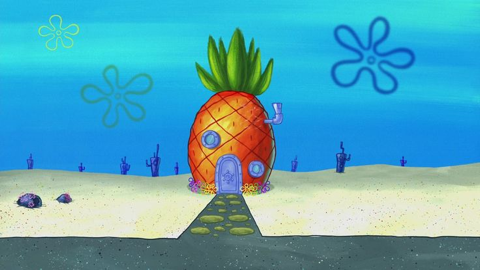
>
> SpongeBob lovingly keeps a precious diary with photos of all his friends. But when he got home after a long day of work at the Krusty Krab, he found a letter from Squidward on top of the diary:
>
> *"Since you annoy me so much, I decided to annoy you too. I tore out 10 random pages of your diary and put impostors in their place. Now your diary is incomplete, and you'll never know where!"*
>
> In despair, SpongeBob asked for your help. **Train a model that finds the impostor pages automatically.**

## Task description

The diary has **3,000 pages** containing pictures of these characters:
- SpongeBob SquarePants
- Patrick Star
- Squidward Tentacles
- Mr. Krabs
- Plankton
- Gary the Snail

Each page is an image with 3 photos of a single character. Exactly **10** of them are impostors: images that don't belong to the original diary.

There is no labeled training set. You have to figure out, from the images alone, which pages stand out from the rest.

## Input

- `data/book.zip`: contains `book/0001.jpg` to `book/3000.jpg`, that is, 3,000 JPEG images
- `data/book_ans.csv`: the 10 impostor pages of the public book (column `page`)
- `data/book_hidden.zip` and `data/book_hidden_ans.csv`: the hidden book used for grading and its answers, used only in the last cell

Each book is about 1.1 GB and lives in the [repository's releases](https://github.com/NOIC-IA/oboia/releases/tag/oboia-2026-impostor). If they aren't in `data/`, the notebook downloads them automatically.

During grading, the hidden book (with different pages and impostors) was placed at the same path as `book.zip`, so nothing had to change.

## Output

The program must create a `predictions.csv` file with **exactly 10 rows**, one per suspicious page:

```csv
page
0042
1337
...
```

`page` is the page number, the same as the file name (from `0001` to `3000`). Repeated pages don't count twice.

## Scoring

Let $k$ be the number of **distinct impostor pages** that appear in your `predictions.csv`. The score grows **exponentially** with $k$, so each extra impostor is worth more than the previous one:

$$\text{score} = \frac{2^{k} - 1}{2^{10} - 1}$$

<table align="center" style="text-align: center">
  <tr><th>Impostors found (<i>k</i>)</th><th>Score</th></tr>
  <tr><td>0</td><td>0.000</td></tr>
  <tr><td>1</td><td>0.001</td></tr>
  <tr><td>2</td><td>0.003</td></tr>
  <tr><td>3</td><td>0.007</td></tr>
  <tr><td>4</td><td>0.015</td></tr>
  <tr><td>5</td><td>0.030</td></tr>
  <tr><td>6</td><td>0.062</td></tr>
  <tr><td>7</td><td>0.124</td></tr>
  <tr><td>8</td><td>0.249</td></tr>
  <tr><td>9</td><td>0.499</td></tr>
  <tr><td><b>10</b></td><td><b>1.000</b></td></tr>
</table>

Each extra impostor roughly **doubles** your score. Finding the 10th is worth as much as the other nine combined.

- Only the **first 10 rows** of the file count. Extra rows are ignored.
- A repeated page counts **only once**.
- `0042` and `42` are the same page.
- If the file has no `page` column, or has a page outside the range `1` to `3000`, the submission is **invalid**.

On the hidden leaderboard, the baseline scored `0.00`, and the best score achieved by the NOIC team was `1.00`.

## Submission

Submit a ZIP file with **exactly one** notebook (`.ipynb`) at the root. The notebook is run from start to finish, on a GPU machine, over the hidden 3,000-page book. When it finishes, it must have created `predictions.csv`:

```csv
page
0042
1337
...
```

- The file has **10 rows** with the suspicious pages, plus the `page` header.
- Page numbers follow the file names, from `0001` to `3000`.
- **Don't** submit a precomputed list of pages: grading runs your code.
- **Don't** include the book, or very large model weights, in the ZIP.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor

### Loading the data
There are a lot of images, so they come in a single ZIP, `data/book.zip`. If it isn't there yet (on Colab or Kaggle, for example), we first download the public book and its answers (`data/book_ans.csv`). On Kaggle, turn on the **Internet** option in the notebook settings so the download works.

During grading, the hidden book was already at `data/book.zip` and there was no answer file, so nothing was downloaded.

In [2]:
import shutil
import urllib.request

DATA = "data"
BOOK_ZIP = f"{DATA}/book.zip"
ANSWERS = f"{DATA}/book_ans.csv"

BOOK_URL = "https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book.zip"
ANSWERS_URL = "https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_ans.csv"


def download(url, destination):
    # Some servers reject Python's default User-Agent (error 403), so we identify ourselves.
    request = urllib.request.Request(url, headers={"User-Agent": "oboia-notebook/1.0"})
    with urllib.request.urlopen(request) as response, open(destination + ".part", "wb") as file:
        shutil.copyfileobj(response, file, length=1024 * 1024)
    os.replace(destination + ".part", destination)  # only rename once the download has finished


# During grading the hidden book is already at data/book.zip: we only download when the file is missing.
if not os.path.exists(BOOK_ZIP):
    os.makedirs(DATA, exist_ok=True)
    print("Downloading book.zip (about 1.1 GB)...")
    download(BOOK_URL, BOOK_ZIP)
    if not os.path.exists(ANSWERS):
        download(ANSWERS_URL, ANSWERS)

Now we unzip the book once into `data/book/` (if the folder already exists, we skip it). We use Python's `zipfile`, which works on any system without needing the `unzip` command.

In [3]:
import zipfile

IMAGES_PATH = f"{DATA}/book"

if not os.path.isdir(IMAGES_PATH):
    with zipfile.ZipFile(BOOK_ZIP) as book:
        book.extractall(DATA)

### Loading CLIP
CLIP is a model that puts text and images in the same latent space, which is perfect for what we want here: comparing pages with text descriptions.

In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device).eval()

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 79439.09it/s]

We'll also store the folder path and the path of each image, to use later. They are named by index, from 0001.jpg to 3000.jpg.

In [5]:
ALL_IMAGES_PATH = [f"{IMAGES_PATH}/{i:04d}.jpg" for i in range(1, len(os.listdir(IMAGES_PATH)) + 1)]

### The approach
The idea is to have one prompt for each SpongeBob character that appears in the diary and compare each page with all of them. A Patrick page, for example, should have a very high similarity with the prompt "Patrick Star". The prompts are in English, which is what CLIP understands best.

Then we just take the pages that match any character the worst, hoping the impostors are among them.

In [6]:
prompts = [
    "SpongeBob SquarePants",
    "Patrick Star",
    "Squidward Tentacles",
    "Mr. Krabs",
    "Plankton",
    "Gary the Snail"
]

### Text embeddings
We'll use CLIP to generate the text embeddings.

In [7]:
text = processor(text=prompts, return_tensors="pt", padding=True).to(device)
with torch.inference_mode():
    outputs = model.get_text_features(**text)
    text_embeddings = outputs.pooler_output
    text_embeddings /= text_embeddings.norm(dim=1, keepdim=True)

text_embeddings.shape

torch.Size([6, 512])

### Cropping the polaroids
Each page has three polaroids, always in the same positions, so we crop just those so CLIP focuses on the characters and not on the decoration. You can check one of the crops here.

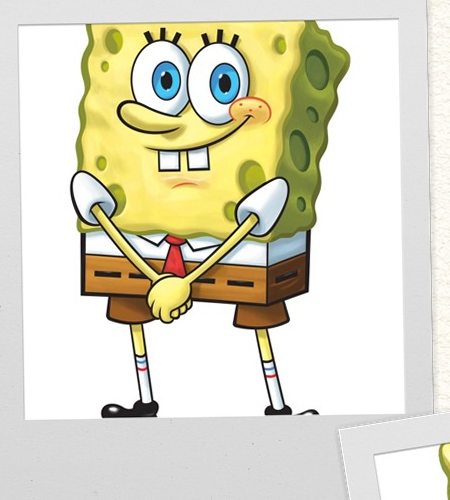

In [8]:
sample_image_path = ALL_IMAGES_PATH[1]

with Image.open(sample_image_path) as sample_image:
    sample_image = sample_image.convert('RGB')

crop_a = (150, 100, 600, 600)
crop_b = (500, 500, 1000, 1000)
crop_c = (150, 900, 600, 1400)

crops = (crop_a, crop_b, crop_c)
sample_image.crop(crop_a)

### Image embeddings
And now the same for the images, in batches. Each page becomes three crops, one per polaroid.

In [9]:
BATCH_SIZE = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if DEVICE == "cuda" else torch.float32

feature_batches = []

for start in range(0, len(ALL_IMAGES_PATH), BATCH_SIZE):
    images = []

    # Open the images in RGB
    for index, path in enumerate(ALL_IMAGES_PATH[start:start + BATCH_SIZE], start):
        with Image.open(path) as image:
            image = image.convert('RGB')
            # The layout alternates sides between pages, so we mirror the even-index ones
            # (files 0001, 0003, ...)
            # so the same crops work for all of them
            if index % 2 == 0:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            for crop in crops:
                images.append(image.crop(crop))

    # Apply CLIP's preprocessing so the images can go into the model
    pixels = processor(
        images=images,
        return_tensors='pt'
    )['pixel_values'].to(DEVICE, dtype=dtype)

    # Extract the embeddings with CLIP and normalize each one
    with torch.inference_mode():
        outputs = model.get_image_features(pixel_values=pixels)
        image_features = outputs.pooler_output
        image_features = image_features / image_features.norm(dim=1, keepdim=True)

    feature_batches.append(image_features.float().cpu().numpy())

    # Show progress every 5 batches
    if start and start % (BATCH_SIZE * 5) == 0:
        print(f'{start}/{len(ALL_IMAGES_PATH)} images embedded')

image_embeddings = np.concatenate(feature_batches)

image_embeddings.shape

640/3000 images embedded


1280/3000 images embedded


1920/3000 images embedded


2560/3000 images embedded


(9000, 512)

### Computing the similarity
Now we can use the `@` operator, which takes the dot product between all image and text embeddings. Since everything is normalized, that's the cosine similarity.

The result has shape `(9000, 6)`: 3 crops for each of the 3,000 pages, with 6 scores each, one per prompt. Then we group each page's crops and sum them, ending up with `(3000, 6)`.

In [10]:
all_scores = image_embeddings @ text_embeddings.cpu().numpy().T
scores_per_image = all_scores.reshape(-1, 3, all_scores.shape[1])
summed_scores = scores_per_image.sum(axis=1)

Now we take the `argmax()` of each page, which is the index of the prompt with the highest score. On a Plankton page, for example, the highest score will probably be the "Plankton" prompt's, and that's the only one that matters for that page.

In [11]:
best = summed_scores.argmax(axis=1)

best

array([1, 0, 1, ..., 0, 5, 1], shape=(3000,))

Let's take a look at all the scores. The `best` column is each page's highest score and `best_idx` is the matching character.

In [12]:
scores = pd.DataFrame(summed_scores)

scores['best'] = summed_scores[
    np.arange(len(summed_scores)),
    best
]

scores['best_idx'] = best

scores

,0,1,2,3,4,5,best,best_idx
0,0.832873,0.961955,0.762400,0.784718,0.817252,0.715774,0.961955,1
1,0.922829,0.805742,0.788159,0.776530,0.807878,0.693700,0.922829,0
2,0.793233,0.918454,0.769767,0.793084,0.785510,0.716977,0.918454,1
3,0.811683,0.768453,0.944570,0.790427,0.842163,0.735274,0.944570,2
4,0.912598,0.804858,0.800771,0.794736,0.789659,0.728867,0.912598,0
...,...,...,...,...,...,...,...,...
2995,0.904258,0.788560,0.764442,0.761508,0.785657,0.701608,0.904258,0
2996,0.803305,0.792878,0.861314,0.822385,0.862971,0.876773,0.876773,5
2997,0.889704,0.794589,0.777584,0.755700,0.798506,0.683062,0.889704,0
2998,0.759036,0.752693,0.810485,0.794237,0.831582,0.841242,0.841242,5


### The worst scores
And now the worst ones. With luck, the impostors are among them.

In [13]:
worst_scores = scores.sort_values("best", ascending=True).head(10)

worst_scores

,0,1,2,3,4,5,best,best_idx
1577,0.558101,0.523217,0.520505,0.553093,0.577445,0.582246,0.582246,5
927,0.527657,0.515921,0.565509,0.586783,0.617984,0.528528,0.617984,4
633,0.586560,0.617497,0.575275,0.596232,0.547878,0.627062,0.627062,5
1168,0.638946,0.641736,0.611069,0.605420,0.571125,0.621137,0.641736,1
2999,0.576501,0.651912,0.622433,0.642091,0.514433,0.638958,0.651912,1
117,0.685214,0.647171,0.678540,0.650336,0.667979,0.684675,0.685214,0
1837,0.561434,0.567597,0.664822,0.601360,0.740003,0.581933,0.740003,4
1495,0.747863,0.676944,0.631009,0.660428,0.690286,0.618577,0.747863,0
1928,0.692992,0.701606,0.727827,0.642453,0.749023,0.714721,0.749023,4
686,0.685167,0.769118,0.672180,0.687263,0.618394,0.655703,0.769118,1


Let's plot them and check by eye.

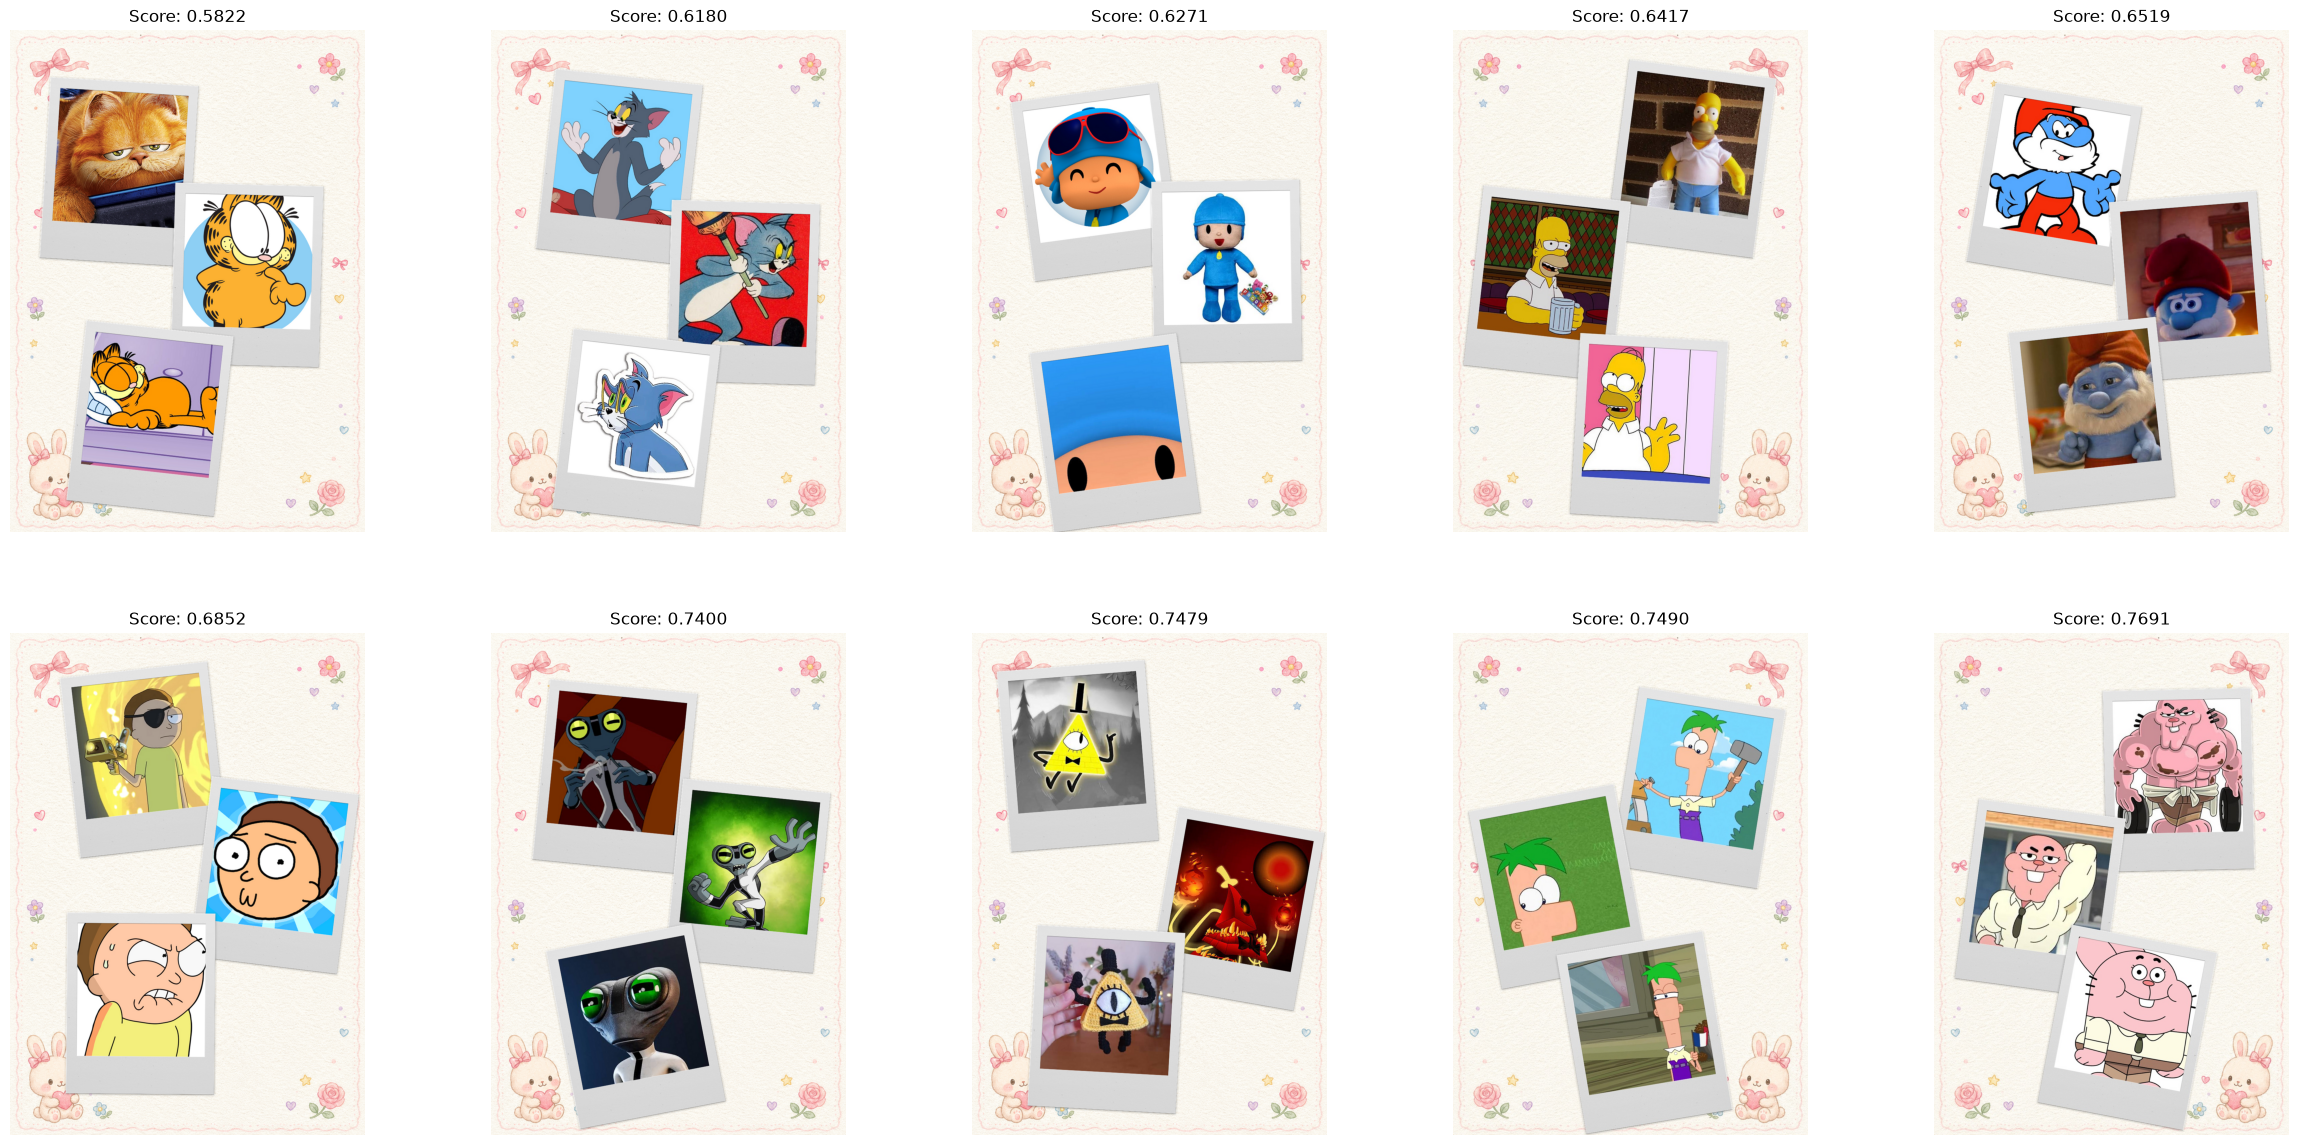

In [14]:
plt.figure(figsize=(30, 30))

for i, idx in enumerate(worst_scores.index):
    img = plt.imread(f"{IMAGES_PATH}/{idx + 1:04d}.jpg")
    plt.subplot(4, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Score: {worst_scores.loc[idx, 'best']:.4f}")
    plt.axis("off")

plt.show()

### Saving the predictions
Finally, we save the 10 candidates to `predictions.csv`, one per row, in the `page` column. The page number is the same as the file name (from `0001` to `3000`).

In [15]:
# Indices start at 0, so the page number is index + 1
pages = [f"{int(idx) + 1:04d}" for idx in worst_scores.index]

predictions = pd.DataFrame({"page": pages})
predictions.to_csv("predictions.csv", index=False)

predictions

,page
0,1578
1,0928
2,0634
3,1169
4,3000
5,0118
6,1838
7,1496
8,1929
9,0687


### Local evaluation
When `data/book_ans.csv` is available, we compute the score the same way grading does: $k$ is the number of distinct impostor pages among the first 10 rows of `predictions.csv`, and

$$\text{score} = \frac{2^{k} - 1}{2^{10} - 1}$$

During private grading this file doesn't exist, so the cell simply moves on without raising an exception.

In [16]:
if os.path.exists(ANSWERS):
    impostors = set(pd.read_csv(ANSWERS, dtype=str)["page"].astype(int))
    predicted = set(pd.read_csv("predictions.csv", dtype=str)["page"].head(10).astype(int))  # "0042" and "42" are the same page

    k = len(predicted & impostors)
    score = (2**k - 1) / (2**10 - 1)

    print(f"Impostors found: {k} of 10")
    print(f"Score on the public book: {score:.3f}")

Impostors found: 10 of 10
Score on the public book: 1.000


### Bonus: score on the hidden book
This wasn't part of the contest: we run the same method on the hidden book used for grading (`data/book_hidden.zip`) and compare it with its answers (`data/book_hidden_ans.csv`). If the files aren't in `data/`, the cell downloads them from the repository's releases.

In [17]:
HIDDEN_ZIP = f"{DATA}/book_hidden.zip"
HIDDEN_ANSWERS = f"{DATA}/book_hidden_ans.csv"
HIDDEN_DIR = f"{DATA}/hidden"

if not os.path.exists(HIDDEN_ZIP):
    print("Downloading book_hidden.zip (about 1.1 GB)...")
    download("https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_hidden.zip", HIDDEN_ZIP)
if not os.path.exists(HIDDEN_ANSWERS):
    download("https://github.com/NOIC-IA/oboia/releases/download/oboia-2026-impostor/book_hidden_ans.csv", HIDDEN_ANSWERS)
if not os.path.isdir(f"{HIDDEN_DIR}/book"):
    with zipfile.ZipFile(HIDDEN_ZIP) as book:
        book.extractall(HIDDEN_DIR)

hidden_pages = [f"{HIDDEN_DIR}/book/{i:04d}.jpg" for i in range(1, len(os.listdir(f"{HIDDEN_DIR}/book")) + 1)]

# Same pipeline as the solution: polaroid crops, similarity with the prompts and the 10 worst scores.
batches = []
for start in range(0, len(hidden_pages), BATCH_SIZE):
    images = []
    for index, path in enumerate(hidden_pages[start:start + BATCH_SIZE], start):
        with Image.open(path) as image:
            image = image.convert("RGB")
            if index % 2 == 0:
                image = image.transpose(Image.Transpose.FLIP_LEFT_RIGHT)
            for crop in crops:
                images.append(image.crop(crop))
    pixels = processor(images=images, return_tensors="pt")["pixel_values"].to(DEVICE, dtype=dtype)
    with torch.inference_mode():
        features = model.get_image_features(pixel_values=pixels).pooler_output
        features = features / features.norm(dim=1, keepdim=True)
    batches.append(features.float().cpu().numpy())
hidden_embeddings = np.concatenate(batches)

hidden_scores = (hidden_embeddings @ text_embeddings.cpu().numpy().T).reshape(-1, 3, len(prompts)).sum(axis=1)
best_score = hidden_scores.max(axis=1)
hidden_predicted = {int(i) + 1 for i in np.argsort(best_score, kind="stable")[:10]}

hidden_impostors = set(pd.read_csv(HIDDEN_ANSWERS, dtype=str)["page"].astype(int))
hidden_k = len(hidden_predicted & hidden_impostors)

print(f"Impostors found in the hidden book: {hidden_k} of 10")
print(f"Score on the hidden book: {(2**hidden_k - 1) / (2**10 - 1):.3f}")

Impostors found in the hidden book: 10 of 10
Score on the hidden book: 1.000


Let's look at the 10 pages picked in the hidden book, marking which ones are real impostors.

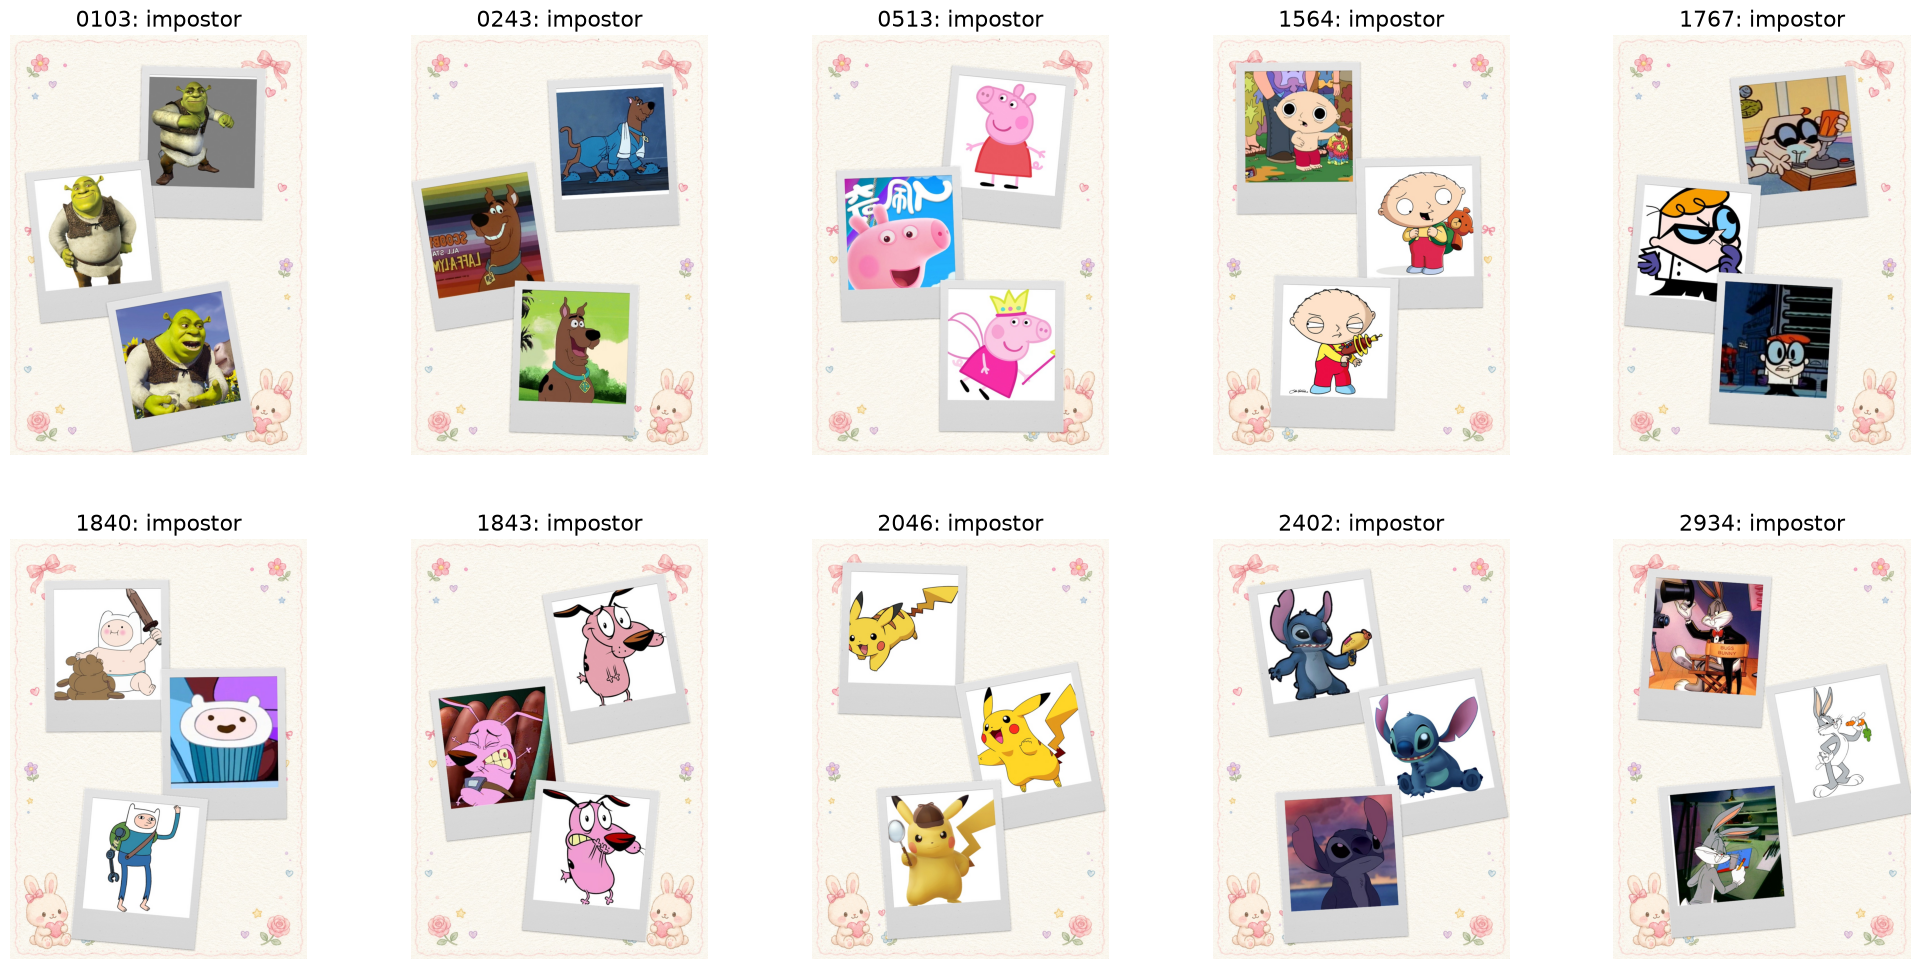

In [18]:
plt.figure(figsize=(25, 12))

for i, page in enumerate(sorted(hidden_predicted)):
    plt.subplot(2, 5, i + 1)
    plt.imshow(plt.imread(f"{HIDDEN_DIR}/book/{page:04d}.jpg"))
    plt.title(f"{page:04d}: " + ("impostor" if page in hidden_impostors else "not an impostor"), fontsize=16)
    plt.axis("off")

plt.show()